# IT Incident Dataset 
<h2 style="color:#2F5597; font-size:36px;">Stage 1 : Data Understanding</h2>

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
incident_df = pd.read_csv("data/incident_event_log.csv")

incident_df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## Checking the First Few Rows

Looking at the first 5 rows gives a quick idea of what the data looks like.

The first thing that stands out is that the same incident number INC0000045 
appears multiple times with different states like New, Resolved and Closed. 
This suggests the dataset is an event log where each row is a state change 
rather than one row per incident.

The data includes columns like incident state, priority, reassignment count 
and timestamps like opened_at which will be useful later for calculating 
how long each incident took to resolve.

## Dataset Size

In [12]:
# checking dataset size
incident_df.shape

(141712, 36)

So the dataset has 141,712 rows and 36 columns.

That is quite a lot of data which is good because more data usually means 
the model will train better later on.

The 36 columns cover different things about each inc.losed.

## Column Overview

In [13]:
# checking column names
incident_df.columns.tolist()

['number',
 'incident_state',
 'active',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'made_sla',
 'caller_id',
 'opened_by',
 'opened_at',
 'sys_created_by',
 'sys_created_at',
 'sys_updated_by',
 'sys_updated_at',
 'contact_type',
 'location',
 'category',
 'subcategory',
 'u_symptom',
 'cmdb_ci',
 'impact',
 'urgency',
 'priority',
 'assignment_group',
 'assigned_to',
 'knowledge',
 'u_priority_confirmation',
 'notify',
 'problem_id',
 'rfc',
 'vendor',
 'caused_by',
 'closed_code',
 'resolved_by',
 'resolved_at',
 'closed_at']

The dataset has 36 columns in total. Looking through them I can group 
them into a few different types.

Incident details like incident_state, priority, category and contact_type 
tell us what kind of incident it is and how serious it is.

Time columns like opened_at, resolved_at and closed_at will be useful 
later for working out how long each incident took to resolve.

Activity columns like reassignment_count, reopen_count and sys_mod_count 
show how much work went into handling each incident.

Boolean columns like active, made_sla and knowledge just hold a True 
or False value.

Some columns like caused_by, vendor, cmdb_ci and problem_id look like 
they might have a lot of missing data which is something to check next.

## Checking Data Types

In [30]:
# checking data types
incident_df.dtypes

number                             object
incident_state                     object
active                               bool
reassignment_count                  int64
reopen_count                        int64
sys_mod_count                       int64
made_sla                             bool
caller_id                          object
opened_by                          object
opened_at                  datetime64[ns]
sys_created_by                     object
sys_created_at                     object
sys_updated_by                     object
sys_updated_at                     object
contact_type                       object
location                           object
category                           object
subcategory                        object
u_symptom                          object
impact                             object
urgency                            object
priority                           object
assignment_group                   object
assigned_to                       

Looking at the data types, most columns are stored as object which means 
they are text or categorical data.

Three columns  reassignment_count, reopen_count and sys_mod_count are 
stored as int64 which means they are whole numbers. These are the only 
true numerical columns in the dataset.

Four columns  active, made_sla, knowledge and u_priority_confirmation
are stored as bool meaning they only hold True or False values.

The most important thing I noticed here is that opened_at, resolved_at 
and closed_at are all stored as object instead of datetime. This means 
they are being treated as text right now. These columns will need to be 
converted to datetime format in Stage 2 so that resolution time can be 
calculated properly.

Also columns like priority, impact, urgency and category are stored as 
object even though they hold category values. These will need to be 
encoded into numbers before the model can use them.odel can use them.

## Missing Value Check

In [15]:
# checking missing values in each column
incident_df.isnull().sum().sort_values(ascending=False)

number                     0
incident_state             0
impact                     0
urgency                    0
priority                   0
assignment_group           0
assigned_to                0
knowledge                  0
u_priority_confirmation    0
notify                     0
problem_id                 0
rfc                        0
vendor                     0
caused_by                  0
closed_code                0
resolved_by                0
resolved_at                0
cmdb_ci                    0
u_symptom                  0
subcategory                0
opened_by                  0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
caller_id                  0
opened_at                  0
category                   0
sys_created_by             0
sys_created_at             0
sys_updated_by             0
sys_updated_at             0
contact_type               0
location      

the dataset shows zero missing values across 
all 36 columns. At first this looks great.

But I was not fully convinced because in real world datasets missing 
values are sometimes hidden using placeholder values like a question mark 
or a dash instead of a proper null value.

So the next step was to check if any columns contain a ? symbol which 
is a common way missing data gets stored in IT system export

In [16]:
# checking ? values used as missing data
(incident_df == "?").sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Hidden Missing Values Found

As I suspected, the dataset does have missing values they were just 
hidden as a ? symbol instead of proper nulls.

The results show that some columns have a huge amount of missing data. 
caused_by, vendor, cmdb_ci, rfc and problem_id all have over 99% of 
their rows as ?, meaning they are basically empty and will not be useful 
for the model.

sys_created_at and sys_created_by both have 53,076 missing values which 
is also very high.

resolved_at has 3,141 missing values which is important to note because 
this column will be used to calculate resolution time later. Rows where 
resolved_at is missing cannot be used for that calculation.

On the other hand, important columns like priority, impact, urgency, 
incident_state and contact_type have zero missing values which is good 
news as these are the main features we plan to use for prediction.

This was an important finding because it shows the real data quality 
issues that were hidden at first glance.

# Exploratory Data Analysis 
The following visualisations explore the distribution of key features in the dataset 
to identify patterns, imbalances, and relationships between variables.

## 1. Incident State Distribution

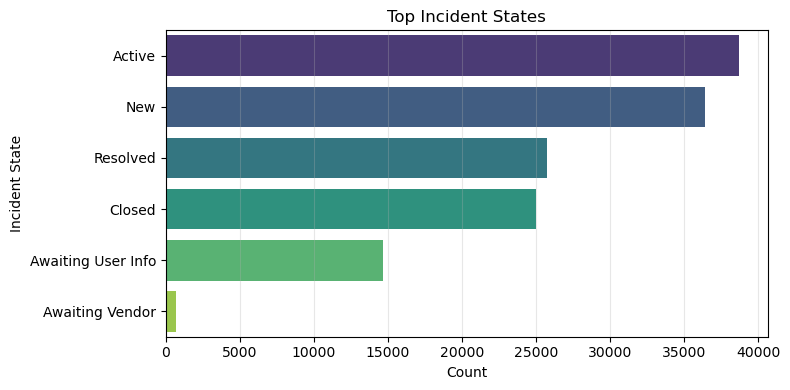

In [28]:
state_count=incident_df["incident_state"].value_counts().head(6).reset_index()
state_count.columns=["incident_state","count"]

plt.figure(figsize=(8,4))
sns.barplot(data=state_count,x="count",y="incident_state",hue="incident_state",palette="viridis",legend=False)
plt.title("Top Incident States")
plt.xlabel("Count")
plt.ylabel("Incident State")
plt.grid(axis="x",alpha=0.3)
plt.tight_layout()
plt.show()

The bar chart shows how incidents are spread across different states in the dataset.

Active and New have the highest counts, with both above 34,000. This means 
a large portion of incidents were still open or newly created at the time 
the data was recorded.

Resolved and Closed follow with around 22,000 to 23,000 each, showing that 
a good number of incidents were completed successfully.

Awaiting User Info has around 13,000 incidents. These are cases where the 
support team is waiting for the user to respond before the incident can move 
forward.

Awaiting Problem is very rare in the dataset, shown by the tiny bar at the 
bottom.

This tells us that most incidents in this dataset are either still being 
worked on or have already been closed, which is normal for IT support data.

## 2. Priority Distribution

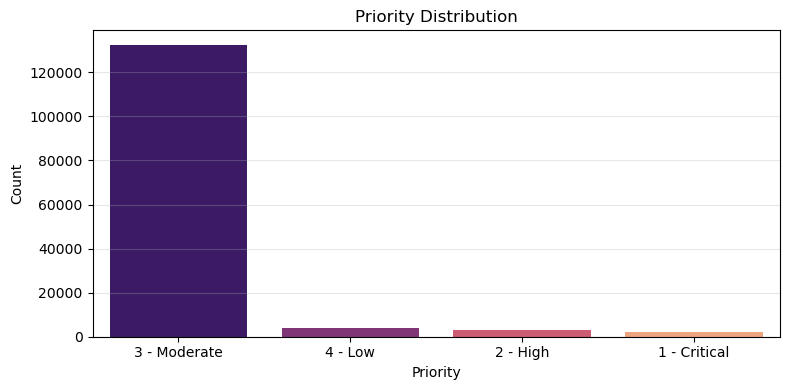

In [29]:
priority_count=incident_df["priority"].value_counts().reset_index()
priority_count.columns=["priority","count"]

plt.figure(figsize=(8,4))
sns.barplot(data=priority_count,x="priority",y="count",hue="priority",palette="magma",legend=False)
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

Looking at the chart, most incidents fall under 3 - Moderate priority. 
The count is over 130,000 which is way higher than the rest.

4 - Low and 2 - High are both quite small, around 3,000 to 5,000 each. 
1 - Critical is the smallest of all four.

This tells me the data is not balanced at all. Almost everything is 
moderate priority. In a real IT support system this kind of makes sense 
because serious problems do not happen that often.

One thing to keep in mind is that this imbalance might cause issues later 
when building the model, since it will mostly learn from moderate cases 
and might struggle with high or critical ones.

## Understanding Incident Structure

In [18]:
# checking how many times each incident appears
incident_df["number"].value_counts().head(10)

number
INC0019396    58
INC0044260    56
INC0005927    46
INC0020718    45
INC0011206    44
INC0025734    43
INC0007349    43
INC0012815    40
INC0003419    38
INC0032450    38
Name: count, dtype: int64

In [19]:
# checking total number of unique incidents in the dataset
incident_df["number"].nunique()

24918

To understand the structure of the dataset, the number of occurrences of each incident was checked.

It was found that the same incident number appears multiple times. For example, some incidents appear more than 50 times.

The dataset contains 24,918 unique incidents, while the total number of rows is much higher.

This shows that the dataset is not a simple one-row-per-incident dataset, but an event log, where each row represents an update or change in an incident.

This is important because it affects how the data will be prepared for modeling.

This means that a decision will be needed later on whether to use event-level data or convert it into one row per incident for modeling.

## Duplicate Row Check

In [20]:
# checking exact duplicate rows
incident_df.duplicated().sum()

0

Checking for exact duplicate rows came back as 0.

This means even though the same incident number appears many times, 
each row is actually different. The rows differ because each one 
captures a different state or update at a different point in time.

So the repeated rows are not a data quality issue, they are just 
how the event log works.

## Initial Target Direction

Based on what I have seen so far, the plan is to predict how long an 
incident takes to resolve. This is called resolution time.

The columns opened_at and resolved_at can be used to calculate this. 
The difference between these two timestamps will give the time taken 
to resolve each incident in hours.

This calculated value will become the target variable in Stage 2.

One thing to note is that resolved_at has 3,141 missing values which 
were found earlier. Rows where resolved_at is missing cannot be used 
to calculate resolution time so they will need to be removed in 
Stage 2.

<h2 style="color:#2F5597;font-size:36px ">Stage 2 : Data Preparation</h2>

## Replacing Hidden Missing Values

In the dataset, missing values were represented using the `"?"` symbol instead of proper null values.

To ensure accurate data cleaning and analysis, these values are replaced with `NaN`.

In [21]:
# replacing ? with proper missing values NaN
incident_df = incident_df.replace("?", pd.NA)

In [22]:
# checking missing values again after replacement
incident_df.isnull().sum().sort_values(ascending=False)

caused_by                  141689
vendor                     141468
cmdb_ci                    141267
rfc                        140721
problem_id                 139417
sys_created_at              53076
sys_created_by              53076
u_symptom                   32964
assigned_to                 27496
assignment_group            14213
opened_by                    4835
resolved_at                  3141
closed_code                   714
resolved_by                   226
subcategory                   111
category                       78
location                       76
caller_id                      29
priority                        0
notify                          0
u_priority_confirmation         0
knowledge                       0
number                          0
urgency                         0
impact                          0
incident_state                  0
contact_type                    0
sys_updated_at                  0
sys_updated_by                  0
opened_at     

## Missing Values After Replacement

After replacing `"?"` with `NaN`, the missing values in the dataset became clearly visible.

It was observed that several columns contain a very high number of missing values. For example, columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have missing values in almost all rows.

Some columns, including `sys_created_at`, `sys_created_by`, `u_symptom`, `assigned_to`, and `assignment_group`, contain a moderate number of missing values.

On the other hand, important columns such as `priority`, `impact`, `urgency`, and `incident_state` do not contain missing values and can be used reliably for analysis.

This step is important because it reveals the true data quality and helps in deciding how to handle missing values in the next steps.

## Removing Highly Missing Columns

In [23]:
# dropping columns with too many missing values
incident_df = incident_df.drop(
    columns=["caused_by", "vendor", "cmdb_ci", "rfc", "problem_id"]
)

In [24]:
# checking missing values again after dropping columns
incident_df.isnull().sum().sort_values(ascending=False)

sys_created_at             53076
sys_created_by             53076
u_symptom                  32964
assigned_to                27496
assignment_group           14213
opened_by                   4835
resolved_at                 3141
closed_code                  714
resolved_by                  226
subcategory                  111
category                      78
location                      76
caller_id                     29
impact                         0
priority                       0
urgency                        0
u_priority_confirmation        0
notify                         0
knowledge                      0
number                         0
incident_state                 0
contact_type                   0
sys_updated_at                 0
sys_updated_by                 0
opened_at                      0
made_sla                       0
sys_mod_count                  0
reopen_count                   0
reassignment_count             0
active                         0
closed_at 

Based on the missing value analysis, some columns contain missing values in almost all rows.

Columns such as `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id` have more than 99% missing values and do not provide useful information.

These columns were removed to improve data quality and reduce noise in the dataset.

## Datetime Conversion

In [25]:
# converting date columns to datetime with correct format
incident_df["opened_at"]=pd.to_datetime(incident_df["opened_at"],dayfirst=True,errors="coerce")
incident_df["resolved_at"]=pd.to_datetime(incident_df["resolved_at"],dayfirst=True,errors="coerce")
incident_df["closed_at"]=pd.to_datetime(incident_df["closed_at"],dayfirst=True,errors="coerce")

# checking updated data types
incident_df[["opened_at","resolved_at","closed_at"]].dtypes

opened_at      datetime64[ns]
resolved_at    datetime64[ns]
closed_at      datetime64[ns]
dtype: object

The columns `opened_at`, `resolved_at`, and `closed_at` were converted from object type to datetime format using the correct day-first format.

The parameter `dayfirst=True` ensures that the dates are interpreted correctly as day/month/year.

The parameter `errors="coerce"` converts any invalid or inconsistent date values into missing values.

After conversion, all three columns are now in datetime format, which allows time-based calculations such as incident resolution time in the next step.